In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


((150, 5), None)

In [4]:
df.columns, iris.target_names

(Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
        'petal width (cm)', 'target'],
       dtype='object'),
 array(['setosa', 'versicolor', 'virginica'], dtype='<U10'))

In [5]:
df["target"].value_counts()

,count
target,
0,50
1,50
2,50


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


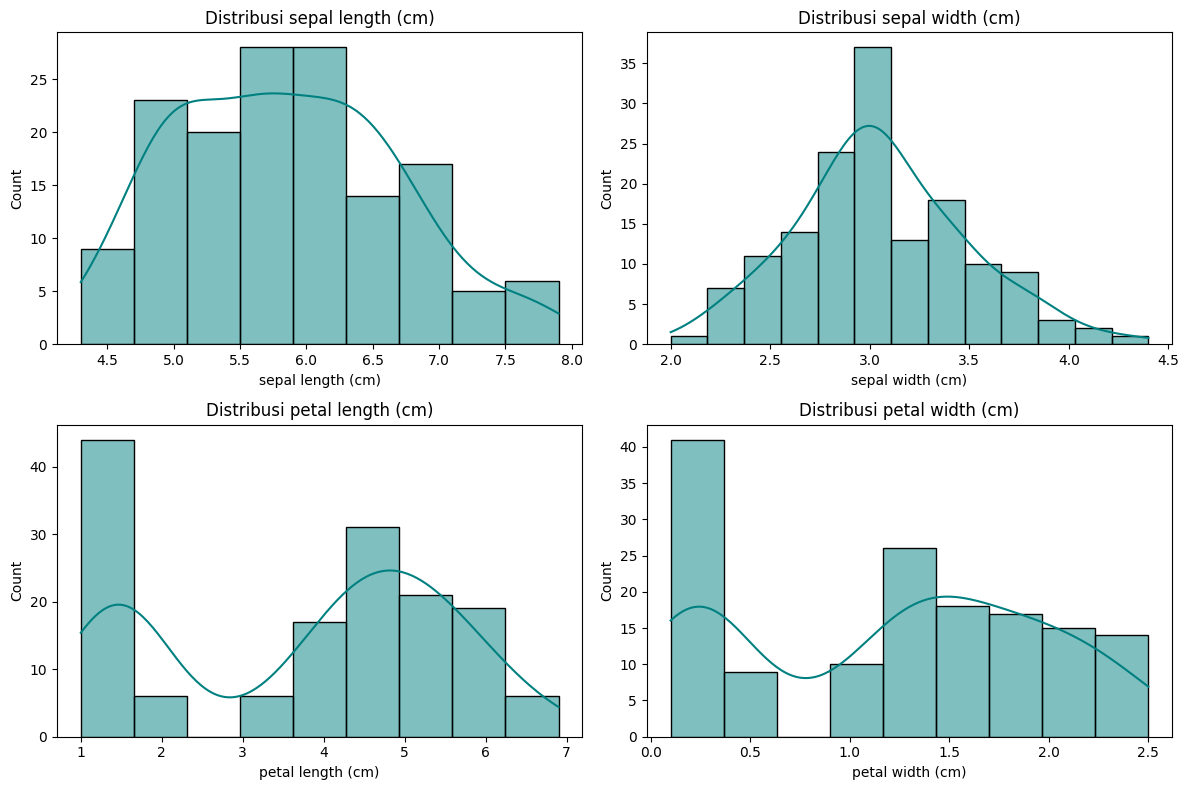

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

features = df.columns[:-1]
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"Distribusi {col}")

plt.tight_layout()
plt.show()

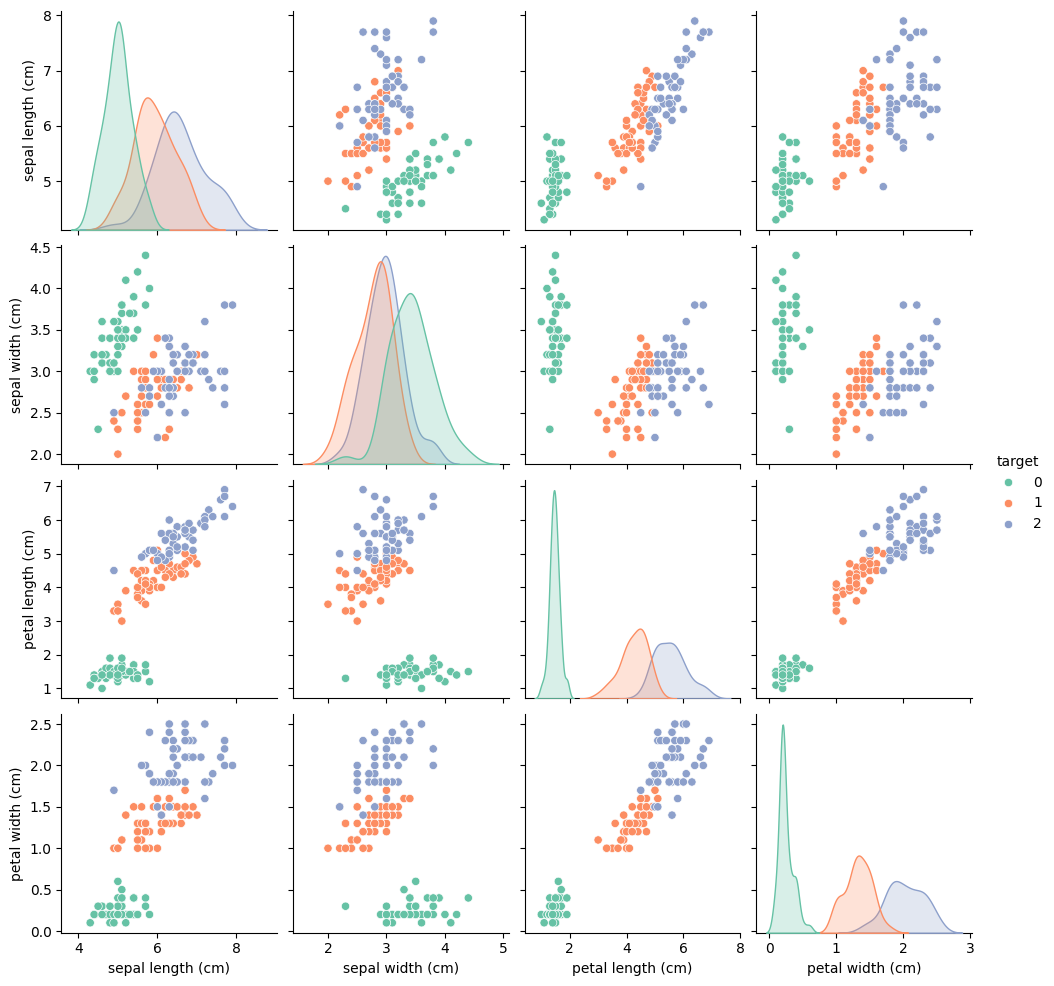

In [9]:
sns.pairplot(df, hue="target", palette="Set2")
plt.show()

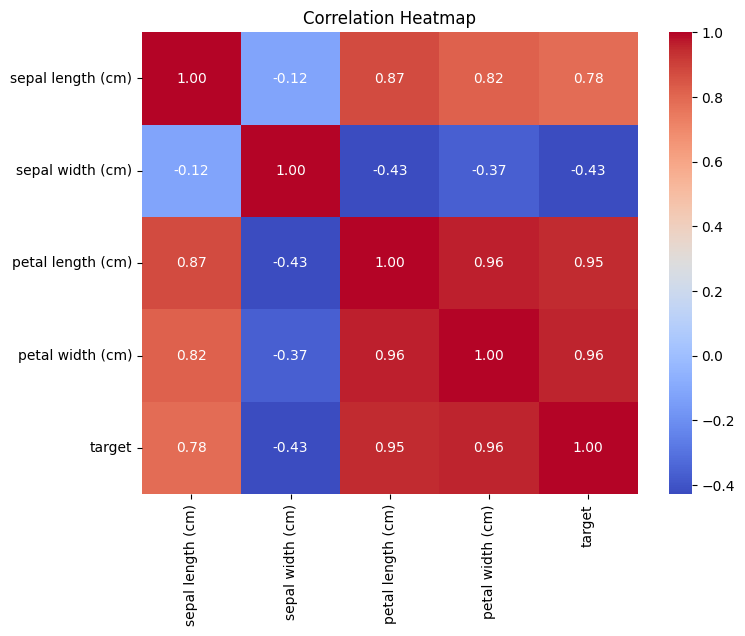

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
X = df.drop(columns=["target"])
y = df["target"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
8,-1.721568,-0.332101,-1.345722,-1.323276
106,-1.124492,-1.227655,0.414505,0.651763
76,1.144395,-0.555990,0.584850,0.256755
9,-1.124492,0.115676,-1.288941,-1.454945
89,-0.408002,-1.227655,0.130598,0.125086


In [16]:
train_processed = X_train_scaled_df.copy()
train_processed["target"] = y_train

test_processed = X_test_scaled_df.copy()
test_processed["target"] = y_test

train_processed.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
8,-1.721568,-0.332101,-1.345722,-1.323276,0
106,-1.124492,-1.227655,0.414505,0.651763,2
76,1.144395,-0.555990,0.584850,0.256755,1
9,-1.124492,0.115676,-1.288941,-1.454945,0
89,-0.408002,-1.227655,0.130598,0.125086,1


In [20]:
import os
os.listdir()

['.config',
 'iris_test_preprocessed.csv',
 'iris_train_preprocessed.csv',
 'sample_data']

In [19]:
train_processed.to_csv("/content/iris_train_preprocessed.csv", index=False)
test_processed.to_csv("/content/iris_test_preprocessed.csv", index=False)

In [21]:
from google.colab import files
files.download("iris_train_preprocessed.csv")
files.download("iris_test_preprocessed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>